In [ ]:
%pip install "tensorflow>=2.15.0" "tqdm>=4.66"

In [3]:
import tensorflow as tf
import tqdm

print("TensorFlow version:", tf.__version__)
print("tqdm version:", tqdm.__version__)

TensorFlow version: 2.21.0
tqdm version: 4.67.3


In [4]:
from gpt_download3 import download_and_load_gpt2

In [5]:
settings, params = download_and_load_gpt2(model_size="124M", models_dir="gpt2")

/Users/sanjaygudla/Documents/LLM/.venv/lib/python3.11/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'openaipublic.blob.core.windows.net'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 177kiB/s]
/Users/sanjaygudla/Documents/LLM/.venv/lib/python3.11/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'openaipublic.blob.core.windows.net'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
encoder.json: 100%|██████████| 1.04M/1.04M [00:02<00:00, 489kiB/s] 
/Users/sanjaygudla/Documents/LLM/.venv/lib/python3.11/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is b

In [6]:
print("Settings:", settings)
print("Parameter dictionary keys:", params.keys())

Settings: {'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}
Parameter dictionary keys: dict_keys(['blocks', 'b', 'g', 'wpe', 'wte'])


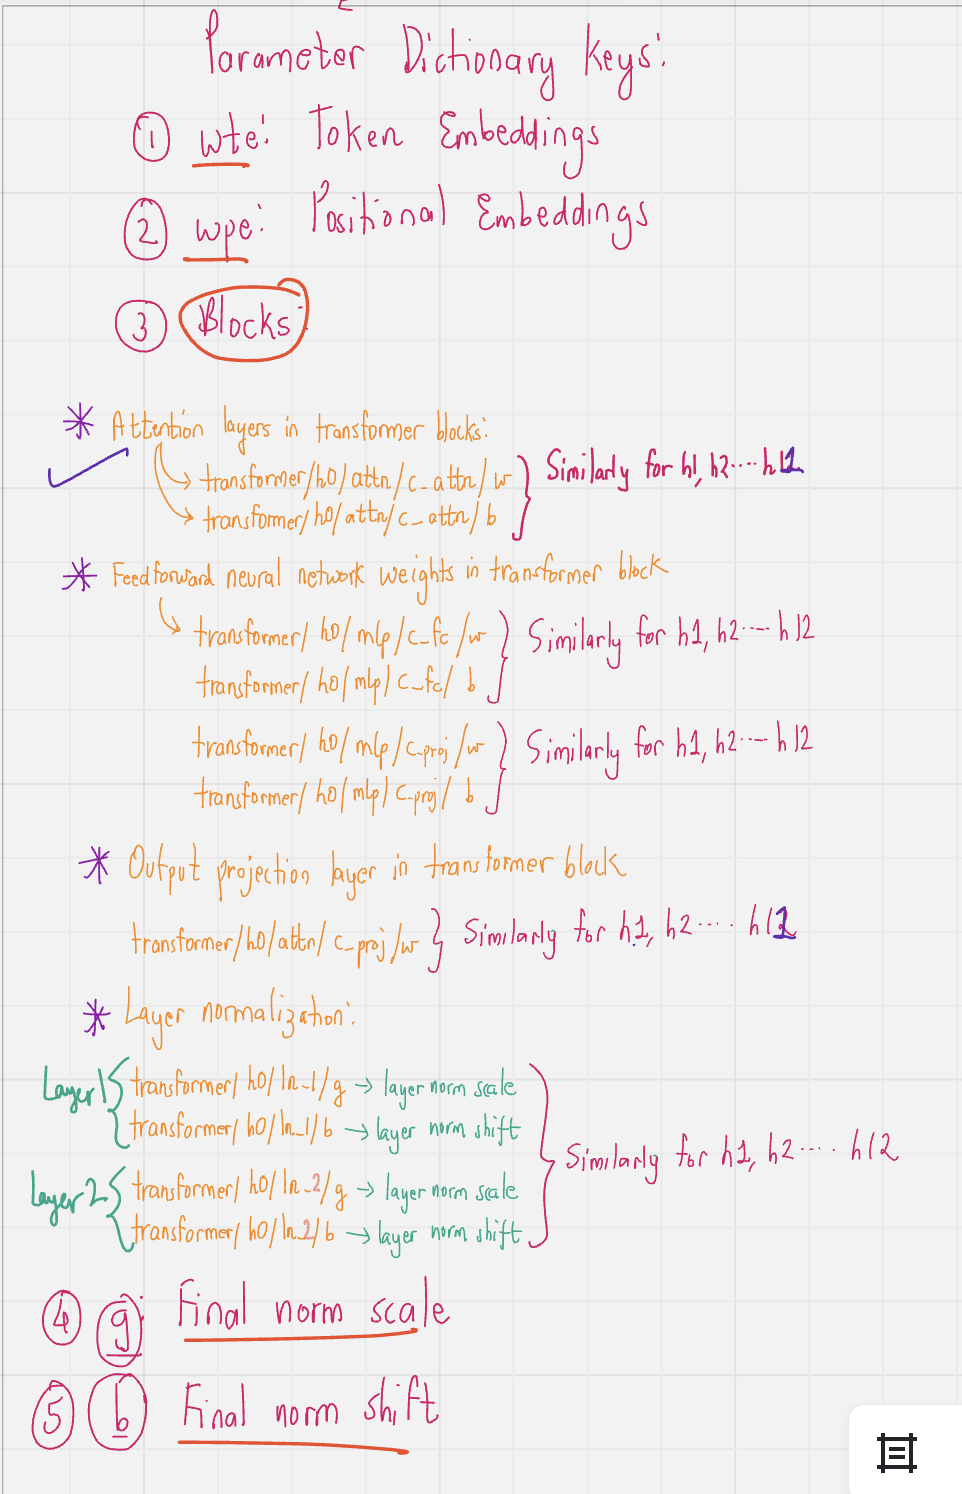

1. h0 - means 1st transformed block, h1 - means 2nd transformer block, .............

2. w - weights, b - biases

2. c_attn is fused matrix of QKV

3. c_fc is fully connected layer

4. c_proj - projection layer

5. ln_1 is layer normalization 1 (g-scale, b-shift)

<div class="alert alert-block alert-success">
    
Both settings and params are Python dictionaries. The settings dictionary stores the LLM
architecture settings similarly to our manually defined GPT_CONFIG_124M settings. 

The
params dictionary contains the actual weight tensors. 

    
Note that we only printed the
dictionary keys because printing the weight contents would take up too much screen space
</div>

In [11]:
import sys
sys.path.append("../../")
from gpt2_model import *




# Define model configurations in a dictionary for compactness
model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

# Copy the base configuration and update with specific model settings
model_name = "gpt2-small (124M)"  # Example model name
NEW_CONFIG = GPT_CONFIG_124M.copy()
NEW_CONFIG.update(model_configs[model_name])


<div class="alert alert-block alert-success">
    
Also, OpenAI used bias vectors in the multi-head attention module's linear layers to
implement the query, key, and value matrix computations. 

Bias vectors are not commonly
used in LLMs anymore as they don't improve the modeling performance and are thus
unnecessary. 

However, since we are working with pretrained weights, we need to match the
settings for consistency and enable these bias vectors:

</div>

In [14]:
NEW_CONFIG.update({"context_length": 1024, "qkv_bias": True})
gpt = GPT2(SimpleNamespace(**NEW_CONFIG))
gpt.eval()

GPT2(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): Transformer(
      (layer_norm1): LayerNorm()
      (layer_norm2): LayerNorm()
      (multi_head_attention): MultiHeadAttention(
        (query_matrix): Linear(in_features=768, out_features=768, bias=True)
        (key_matrix): Linear(in_features=768, out_features=768, bias=True)
        (value_matrix): Linear(in_features=768, out_features=768, bias=True)
        (drop_out): Dropout(p=0.1, inplace=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
      )
      (feed_forward_nn): FeedForwardNN(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): Transformer(
      (layer_norm1): Layer

Helper Function

In [16]:
def assign(left, right):
    if left.shape != right.shape:
        raise ValueError(f"Shape mismatch. Left: {left.shape}, Right: {right.shape}")
    return torch.nn.Parameter(torch.tensor(right))

<div class="alert alert-block alert-info">

Step 1: Setting the model's positional and token embedding weights to those specified in params.

Step 2: Iterate over each transformer block in the model.

Step 3: The np.split function is used to divide the attention and bias weights into three equal parts for the query,
key, and value components.
    
Step 4: The original GPT-2 model by OpenAI reused the token embedding weights in the output layer to reduce the
total number of parameters, which is a concept known as weight tying.

</div>

In [25]:
import numpy as np

def load_weights_into_gpt(gpt, params):
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe'])
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params['wte'])
    
    for b in range(len(params["blocks"])):
        q_w, k_w, v_w = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)
        gpt.trf_blocks[b].multi_head_attention.query_matrix.weight = assign(
            gpt.trf_blocks[b].multi_head_attention.query_matrix.weight, q_w.T)
        gpt.trf_blocks[b].multi_head_attention.key_matrix.weight = assign(
            gpt.trf_blocks[b].multi_head_attention.key_matrix.weight, k_w.T)
        gpt.trf_blocks[b].multi_head_attention.value_matrix.weight = assign(
            gpt.trf_blocks[b].multi_head_attention.value_matrix.weight, v_w.T)

        q_b, k_b, v_b = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
        gpt.trf_blocks[b].multi_head_attention.query_matrix.bias = assign(
            gpt.trf_blocks[b].multi_head_attention.query_matrix.bias, q_b)
        gpt.trf_blocks[b].multi_head_attention.key_matrix.bias = assign(
            gpt.trf_blocks[b].multi_head_attention.key_matrix.bias, k_b)
        gpt.trf_blocks[b].multi_head_attention.value_matrix.bias = assign(
            gpt.trf_blocks[b].multi_head_attention.value_matrix.bias, v_b)

        gpt.trf_blocks[b].multi_head_attention.out_proj.weight = assign(
            gpt.trf_blocks[b].multi_head_attention.out_proj.weight, 
            params["blocks"][b]["attn"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].multi_head_attention.out_proj.bias = assign(
            gpt.trf_blocks[b].multi_head_attention.out_proj.bias, 
            params["blocks"][b]["attn"]["c_proj"]["b"])

        gpt.trf_blocks[b].feed_forward_nn.layers[0].weight = assign(
            gpt.trf_blocks[b].feed_forward_nn.layers[0].weight, 
            params["blocks"][b]["mlp"]["c_fc"]["w"].T)
        gpt.trf_blocks[b].feed_forward_nn.layers[0].bias = assign(
            gpt.trf_blocks[b].feed_forward_nn.layers[0].bias, 
            params["blocks"][b]["mlp"]["c_fc"]["b"])
        gpt.trf_blocks[b].feed_forward_nn.layers[2].weight = assign(
            gpt.trf_blocks[b].feed_forward_nn.layers[2].weight, 
            params["blocks"][b]["mlp"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].feed_forward_nn.layers[2].bias = assign(
            gpt.trf_blocks[b].feed_forward_nn.layers[2].bias, 
            params["blocks"][b]["mlp"]["c_proj"]["b"])

        gpt.trf_blocks[b].layer_norm1.scale = assign(
            gpt.trf_blocks[b].layer_norm1.scale, 
            params["blocks"][b]["ln_1"]["g"])
        gpt.trf_blocks[b].layer_norm1.shift = assign(
            gpt.trf_blocks[b].layer_norm1.shift, 
            params["blocks"][b]["ln_1"]["b"])
        gpt.trf_blocks[b].layer_norm2.scale = assign(
            gpt.trf_blocks[b].layer_norm2.scale, 
            params["blocks"][b]["ln_2"]["g"])
        gpt.trf_blocks[b].layer_norm2.shift = assign(
            gpt.trf_blocks[b].layer_norm2.shift, 
            params["blocks"][b]["ln_2"]["b"])

    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])



<div class="alert alert-block alert-success">

In the load_weights_into_gpt function, we carefully match the weights from OpenAI's
implementation with our GPTModel implementation. 

To pick a specific example, OpenAI
stored the weight tensor for the output projection layer for the first transformer block as
params["blocks"][0]["attn"]["c_proj"]["w"]. 
                                                        
In our implementation, this weight
tensor corresponds to gpt.trf_blocks[b].att.out_proj.weight, where gpt is a
GPTModel instance.
</div>

In [27]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
load_weights_into_gpt(gpt, params)
gpt.to(device)

GPT2(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): Transformer(
      (layer_norm1): LayerNorm()
      (layer_norm2): LayerNorm()
      (multi_head_attention): MultiHeadAttention(
        (query_matrix): Linear(in_features=768, out_features=768, bias=True)
        (key_matrix): Linear(in_features=768, out_features=768, bias=True)
        (value_matrix): Linear(in_features=768, out_features=768, bias=True)
        (drop_out): Dropout(p=0.1, inplace=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
      )
      (feed_forward_nn): FeedForwardNN(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): Transformer(
      (layer_norm1): Layer

In [31]:
torch.manual_seed(123)

import tiktoken
tokenizer = tiktoken.get_encoding('gpt2')

def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0) # add batch dimension
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0) # remove batch dimension
    return tokenizer.decode(flat.tolist())

def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):

    # For-loop is the same as before: Get logits, and only focus on last time step
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]

        # New: Filter logits with top_k sampling
        if top_k is not None:
            # Keep only top_k values
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]
            logits = torch.where(logits < min_val, torch.tensor(float("-inf")).to(logits.device), logits)

        # New: Apply temperature scaling
        if temperature > 0.0:
            logits = logits / temperature

            # Apply softmax to get probabilities
            probs = torch.softmax(logits, dim=-1)  # (batch_size, context_len)

            # Sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1)  # (batch_size, 1)

        # Otherwise same as before: get idx of the vocab entry with the highest logits value
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)  # (batch_size, 1)

        if idx_next == eos_id:  # Stop generating early if end-of-sequence token is encountered and eos_id is specified
            break

        # Same as before: append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch_size, num_tokens+1)

    return idx


token_ids = generate(
    model=gpt,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=25,
    context_size=NEW_CONFIG["context_length"],
    top_k=50,
    temperature=1.5
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you toward finding an ideal new way to practice something!

What makes us want to be on top of that?


